# Model Development

## 1. Loading and Splitting datasets


We are going to reload the cleaned and realy datasets from previous step, and split them into 80-20 ratio of train-test. Since the datasets are bias (only 6% Fraud ratio), we are using stratify to make sure the are split evenly with the same fraud ratio.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_full = pd.read_csv('data/processed/claims_full.csv')
df_selected = pd.read_csv('data/processed/claims_selected.csv')

In [2]:

# separate features and target for each dataset
X_full = df_full.drop(columns='FraudFound')
y_full = df_full['FraudFound']

X_selected = df_selected.drop(columns='FraudFound')
y_selected = df_selected['FraudFound']

# Split - stratify ensures same froud ratio in train and test
X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

X_selected_train, X_selected_test, y_selected_train, y_selected_test = train_test_split(
    X_selected, y_selected, test_size=0.2, random_state=42, stratify=y_selected)

## 2. Train Baseline Model

Our baseline model chosen for this is Logistic Regression and the reasons are as below:
- Simple,fast and interpretable - good starting point nefore we try complex models
- Works well for binary classification (`Fraud` vs `Not Fraud`)
- Coefficients are interpretable - we can see which features push toward fraud

However there are some limitations using this model:
- Assumes linear relatinship between features and the log-odds of fraud
- Sensitive to feature scaling - we will show how using `StandardScalar` before fitting might impact our model performance

We are going to move stage by stage in evaluating and comparing the performance  of our logistic regression model trained on both datasets. We will focus on **F1-score** and **ROC-AUC** as our primary metrics.

F1-score balances precision and recall which is important in fraud detection where false negatives are costly. A false negative occurs when the model predict a claim as legitimate when it is actually fraudulent -- meaning the insurance company processes and pays out a fraudulent claim which leads to financial loss to the company. Therefore, minimising false negatives is critical, which is why **recall**(recall measures how well the model cathces actual fraud cases) is an important consideration.

ROC-AUC on the other hand measures how well the model distinguishes between fraudulent and legitimate claims overall.

### 2.1 Stage 1 - Base Model

We are going to use Linear Regression with no  **class-weight** fitting and feature scaling.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

#train on full features
lr_full_s1 = LogisticRegression(max_iter=1000, random_state = 42)
lr_full_s1.fit(X_full_train, y_full_train)

#train on selected features
lr_selected_s1 = LogisticRegression(max_iter=1000, random_state = 42)
lr_selected_s1.fit(X_selected_train, y_selected_train)

# Predictions on test sets
y_full_pred_s1 = lr_full_s1.predict(X_full_test)
y_selected_pred_s1 = lr_selected_s1.predict(X_selected_test)

# Predicted probabilities (class 1 = fraud)
y_full_proba_s1 = lr_full_s1.predict_proba(X_full_test)[:,1]
y_selected_proba_s1 = lr_selected_s1.predict_proba(X_selected_test)[:,1]

# Evaluate
print("=== Full Features ===")
print(classification_report(y_full_test, y_full_pred_s1))
print("ROC-AUC:", round(roc_auc_score(y_full_test, y_full_proba_s1),2))
print("Confusion Matrix:")
print(confusion_matrix(y_full_test,y_full_pred_s1))

print("=== Selected Features ===")
print(classification_report(y_selected_test, y_selected_pred_s1))
print("ROC-AUC:", round(roc_auc_score(y_selected_test, y_selected_proba_s1),2))
print("Confusion Matrix:")
print(confusion_matrix(y_selected_test,y_selected_pred_s1))


/opt/homebrew/Caskroom/miniconda/base/envs/carclaims/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Full Features ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.00      0.00      0.00       185

    accuracy                           0.94      3084
   macro avg       0.47      0.50      0.48      3084
weighted avg       0.88      0.94      0.91      3084

ROC-AUC: 0.72
Confusion Matrix:
[[2899    0]
 [ 185    0]]
=== Selected Features ===
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.00      0.00      0.00       185

    accuracy                           0.94      3084
   macro avg       0.47      0.50      0.48      3084
weighted avg       0.88      0.94      0.91      3084

ROC-AUC: 0.7
Confusion Matrix:
[[2899    0]
 [ 185    0]]


/opt/homebrew/Caskroom/miniconda/base/envs/carclaims/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/Caskroom/miniconda/base/envs/carclaims/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/hom

There are all 0 values for precision, recall and f1-score for class 1 meaning that this model cannot find any fraudulent claims. 

### 2.2 Stage 2 - Addressing Class Imbalance

We are going to use Linear Regression with **class_weight**=balance fitting.

In [4]:
#train on full features
lr_full_s2 = LogisticRegression(max_iter=1000, random_state = 42, class_weight='balanced')
lr_full_s2.fit(X_full_train, y_full_train)

#train on selected features
lr_selected_s2 = LogisticRegression(max_iter=1000, random_state = 42, class_weight='balanced')
lr_selected_s2.fit(X_selected_train, y_selected_train)

# Predictions on test sets
y_full_pred_s2 = lr_full_s2.predict(X_full_test)
y_selected_pred_s2 = lr_selected_s2.predict(X_selected_test)

# Predicted probabilities (class 1 = fraud)
y_full_proba_s2 = lr_full_s2.predict_proba(X_full_test)[:,1]
y_selected_proba_s2 = lr_selected_s2.predict_proba(X_selected_test)[:,1]

# Evaluate
print("=== Full Features ===")
print(classification_report(y_full_test, y_full_pred_s2))
print("ROC-AUC:", round(roc_auc_score(y_full_test, y_full_proba_s2),2))
print("Confusion Matrix:")
print(confusion_matrix(y_full_test,y_full_pred_s2))

print("=== Selected Features ===")
print(classification_report(y_selected_test, y_selected_pred_s2))
print("ROC-AUC:", round(roc_auc_score(y_selected_test, y_selected_proba_s2),2))
print("Confusion Matrix:")
print(confusion_matrix(y_selected_test,y_selected_pred_s2))


/opt/homebrew/Caskroom/miniconda/base/envs/carclaims/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Full Features ===
              precision    recall  f1-score   support

           0       0.97      0.64      0.77      2899
           1       0.11      0.70      0.19       185

    accuracy                           0.64      3084
   macro avg       0.54      0.67      0.48      3084
weighted avg       0.92      0.64      0.73      3084

ROC-AUC: 0.72
Confusion Matrix:
[[1843 1056]
 [  56  129]]
=== Selected Features ===
              precision    recall  f1-score   support

           0       0.98      0.64      0.77      2899
           1       0.12      0.77      0.21       185

    accuracy                           0.65      3084
   macro avg       0.55      0.70      0.49      3084
weighted avg       0.93      0.65      0.74      3084

ROC-AUC: 0.74
Confusion Matrix:
[[1849 1050]
 [  43  142]]


/opt/homebrew/Caskroom/miniconda/base/envs/carclaims/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Applying `class_weight='balanced'` telss the model to penalise misclassification of fraud cases more heavily,allowing it to start detecting the minority class instead of defaulting everything as legitimate.

The result show that the model now cathes fraud cases - recall improve from 0.00 to 0.72 for slected features.. However precision remain low at 0.12, meaning the model flags many legitimate claims as fraudulent (1030 false positives). Selected features outperform full features across all metrics,confirming that removing non-significant features reduces noise. 

### 2.3 Stage 3 - Feature Scaling

Feature scaling will be applied in this stage to further improve performance.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler_full = StandardScaler()
scaler_selected = StandardScaler()

X_full_train_std = scaler_full.fit_transform(X_full_train)
X_full_test_std = scaler_full.transform(X_full_test)

X_selected_train_std = scaler_selected.fit_transform(X_selected_train)
X_selected_test_std = scaler_selected.transform(X_selected_test)


In [6]:
#train on full features
lr_full_s3 = LogisticRegression(max_iter=1000, random_state = 42, class_weight='balanced')
lr_full_s3.fit(X_full_train_std, y_full_train)

#train on selected features
lr_selected_s3 = LogisticRegression(max_iter=1000, random_state = 42, class_weight='balanced')
lr_selected_s3.fit(X_selected_train_std, y_selected_train)

# Predictions on test sets
y_full_pred_s3 = lr_full_s3.predict(X_full_test_std)
y_selected_pred_s3 = lr_selected_s3.predict(X_selected_test_std)

# Predicted probabilities (class 1 = fraud)
y_full_proba_s3 = lr_full_s3.predict_proba(X_full_test_std)[:,1]
y_selected_proba_s3 = lr_selected_s3.predict_proba(X_selected_test_std)[:,1]

# Evaluate
print("=== Full Features ===")
print(classification_report(y_full_test, y_full_pred_s3))
print("ROC-AUC:", round(roc_auc_score(y_full_test, y_full_proba_s3),2))
print("Confusion Matrix:")
print(confusion_matrix(y_full_test,y_full_pred_s3))

print("=== Selected Features ===")
print(classification_report(y_selected_test, y_selected_pred_s3))
print("ROC-AUC:", round(roc_auc_score(y_selected_test, y_selected_proba_s3),2))
print("Confusion Matrix:")
print(confusion_matrix(y_selected_test,y_selected_pred_s3))




=== Full Features ===
              precision    recall  f1-score   support

           0       0.99      0.61      0.75      2899
           1       0.13      0.88      0.22       185

    accuracy                           0.62      3084
   macro avg       0.56      0.74      0.49      3084
weighted avg       0.94      0.62      0.72      3084

ROC-AUC: 0.8
Confusion Matrix:
[[1760 1139]
 [  22  163]]
=== Selected Features ===
              precision    recall  f1-score   support

           0       0.99      0.61      0.75      2899
           1       0.13      0.90      0.22       185

    accuracy                           0.62      3084
   macro avg       0.56      0.75      0.49      3084
weighted avg       0.94      0.62      0.72      3084

ROC-AUC: 0.8
Confusion Matrix:
[[1755 1144]
 [  19  166]]


Applying `StandardScaler`  standardises all numerical features to the same scale, which is important for logistic regression as it is sensitive to feature magnitude. the scaler is fitted on the training set only and applied to both train and test sets to prevent data leakage.

Scaling further improve recall significantly - from 0.72 to 0.90 for selected features, meaning the model now correctly identify 90% of actual fraud cases. Both datasets perform similarly after scaling, though selected features still show slightly better in recall.

Precision remains low at 0.13,which is expected - this is the ***precision-recall tradeoff*. By prioritising recall (catching fraud), the model casts a wider net and flags more legitimate claims as fraudulent. We can tune this tradeoff via the classification threshold in later iterations. For fraud detection, high recall is the priority as missiing a fraud case leads to direct financial loss for the company.

## 2.4 Baseline Evaluation Summary

The table below combines the metrics from all three stages into one view for easier comparison. From the previous steps, we found that the model with feature scaling and `class_weight='balanced'` performs best. Going forward, we'll focus on the selected feature dataset, as it consistently outperforms the full feature set - likely due to reduced noise from irrelevant features.



In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true,y_pred, y_proba):
    return {"Recall": recall_score(y_true,y_pred),
            "Precision": precision_score(y_true,y_pred),
            "F1-score": f1_score(y_true,y_pred),
            "ROC-AUC": roc_auc_score(y_true,y_proba)}
results = []

# Stage 1
results.append({"Stage":"Stage 1 - Base LR",
                "Feature Set":"Full", 
                **get_metrics(y_full_test, y_full_pred_s1, y_full_proba_s1)}) # ** is dict unpacking operator
results.append({"Stage":"Stage 1 - Base LR",
                "Feature Set":"Selected", 
                **get_metrics(y_selected_test, y_selected_pred_s1, y_selected_proba_s1)}) 

# Stage 2
results.append({"Stage":"Stage 2 - class_weight='balanced'",
                "Feature Set":"Full", 
                **get_metrics(y_full_test, y_full_pred_s2, y_full_proba_s2)}) 
results.append({"Stage":"Stage 2 - class_weight='balanced'",
                "Feature Set":"Selected", 
                **get_metrics(y_selected_test, y_selected_pred_s2, y_selected_proba_s2)}) 

# Stage 3
results.append({"Stage":"Stage 3 - + StandardScaler",
                "Feature Set":"Full", 
                **get_metrics(y_full_test, y_full_pred_s3, y_full_proba_s3)}) 
results.append({"Stage":"Stage 3 - + StandardScaler",
                "Feature Set":"Selected", 
                **get_metrics(y_selected_test, y_selected_pred_s3, y_selected_proba_s3)}) 

summary_df = pd.DataFrame(results)
summary_df = summary_df.round(2)
summary_df

/opt/homebrew/Caskroom/miniconda/base/envs/carclaims/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/carclaims/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Stage,Feature Set,Recall,Precision,F1-score,ROC-AUC
0,Stage 1 - Base LR,Full,0.00,0.00,0.00,0.72
1,Stage 1 - Base LR,Selected,0.00,0.00,0.00,0.70
2,Stage 2 - class_weight='balanced',Full,0.70,0.11,0.19,0.72
3,Stage 2 - class_weight='balanced',Selected,0.77,0.12,0.21,0.74
4,Stage 3 - + StandardScaler,Full,0.88,0.13,0.22,0.80
5,Stage 3 - + StandardScaler,Selected,0.90,0.13,0.22,0.80


Looking at the results, Stage 3 (StandardScaler + `class_weight='balanced'`) achieves the best recall, precision, F1-score and ROC-AUC among all three stages when using the selected feature set. However, the precision remains low (0.13) across all stages, reflecting the ongoing precision-recall tradeoff in this imbalanced dataset. Stage 3 will serve as our reference model going forward as we explore more complex algorithms (Random Forest, XGBoost/LightGBM) and additional techniques (SMOTE, feature engineering) to further improve precision without sacrificing recall.

# 3. Model Tuning

## 3.1 Threshold Tuning

By default the parameter `class_weight='balanced'` use a 0.5 (or 50%) probability threshold to decide whether the claim is a fraudulent or a legitimate one. This is the reason why our model has a good recall value but very low precision. This is the result of precision recall tradeoff. But at 0.5 threshold it's now overflagging tons of legitimate claims as fraud. This can cause upset our customers if their claims were rejected and flagged as fraud. Lets tune this threshold by raising it a little so we can tolerate missiong X% of fraud to avoid flagging too many good customers.

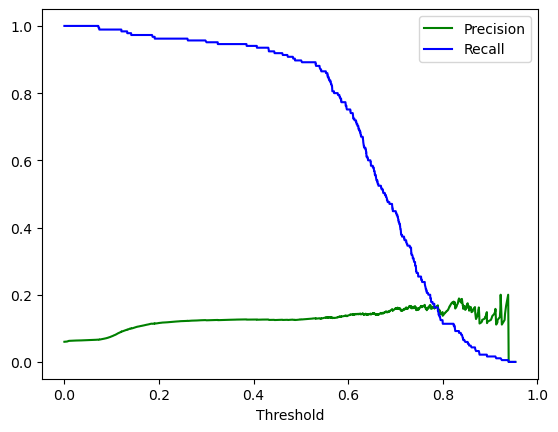

In [8]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_selected_test,y_selected_proba_s3)
plt.plot(thresholds, precision[:-1], "g", label="Precision")
plt.plot(thresholds, recall[:-1],"b",label="Recall")
plt.xlabel('Threshold')
plt.legend()
plt.show()

Looking at the graph above, the precision hover mostly between 0.15-0.18 for threshold between 0.4 to 0.6, where the recall maintained in a good range here. However, the recall drop sharply after threshold of 0.5. We will keep the threshold at 0.5 for now.

## 3.2 Custom Class Weights

In [9]:
results_weight = []

ratios_to_test = [1,3,5,7,9,11,13,15,16,17]

for ratio in ratios_to_test:
    lr = LogisticRegression(max_iter=1000, random_state = 42, class_weight={0:1, 1:ratio})
    lr.fit(X_selected_train_std, y_selected_train)
    # Predictions
    y_pred = lr.predict(X_selected_test_std)
    y_proba = lr.predict_proba(X_selected_test_std)[:,1]
    
    results_weight.append({"Class Weight ratio (0:1):": f"1:{ratio}",
                           **get_metrics(y_selected_test,y_pred,y_proba)})
    
weight_comp_df = pd.DataFrame(results_weight)
weight_comp_df=weight_comp_df.round(2)
weight_comp_df
    

/opt/homebrew/Caskroom/miniconda/base/envs/carclaims/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Class Weight ratio (0:1):,Recall,Precision,F1-score,ROC-AUC
0,1:1,0.00,0.00,0.00,0.80
1,1:3,0.07,0.24,0.11,0.80
2,1:5,0.23,0.17,0.20,0.80
3,1:7,0.47,0.16,0.23,0.80
4,1:9,0.63,0.14,0.23,0.80
5,1:11,0.79,0.14,0.23,0.80
6,1:13,0.86,0.13,0.23,0.80
7,1:15,0.89,0.13,0.22,0.80
8,1:16,0.90,0.13,0.22,0.80
9,1:17,0.91,0.13,0.22,0.79


### Choosing a Class weight Ratio: A Business Trade-off, Not Just a Statistical One

Across the weight ratios tested, recall varies dramatically (0.00 to 0.91) and precision remains consistently low (0.13-0.24), while ROC-AUC stays nearly constant (~0.80). This tell us that class weighting - much like threshold tuning - shifts the model's decision boundary along a fixed precision-recall curve, rather than improving the model's underlying ability to separate fraud from legitimate claims. 

Looking at ratio 1:13 to 1:17, precision barely moves (~0.13), but recall keeps moving up (0.86 -> 0.91). This range also includes ration 1:16, which is approximately what sklearn's `class_weight="balanced"` computes automatically for our dataset (since our fraud class makes up about 6% of the data, `"balanced"` set the weight ratio to 94:6, or about 1:16, to fully compensate the class imbalance). This means that in this range, we can get better recall almost for free. So the choice here is not really about which model performs better statistically but more about business decision instead:

**The case for higher recall (wider net):**
Missing a fraudulent claim means the company directly pays out money it shouldn't which is real, quantifiable loss. A higher recall model casts a wider net,catching more actual fraud cases before they are paid out. This reduces financial loss from fraud.

**The trade-off**
Casting a wider net also means flagging more claims overall - including more legitimate ones - for investigation. Each flagged claim requires human review, so a higher recall model increases the workload on the fraud investigation teams. If this team has limited capacity, this can:
- Overwhelm investigators with a growing backlog
- Delay review of genuinely fraudulent claims, weakening the model's real-world benefit
- Frustrate legitimate customers who experience delays or added review on their claims, potentially harming customer trust and retention

**Making Decision:**
- If the business has **sufficient investigation capacity** (or is willing to scale it), priotizing recall makes sense - the cost of a missed fraud case outweighs the cost of extra investigations.
- If the business is **constrained by investigation capacity** (a fixed team size/budget/turnaround time) then choosing a lower-recall, higher-precison ratio may be more appropriate, ensuring the team can realistically act on every flagged claim without becoming a bottleneck.

This decision ultimately depends on information outside the model itself : 
- The company's investigation capacity
- Cost per investigation
- Average payout to fraudulent claim

Since our sweep shows that a ratio of 1:16 is nearly identical to sklearn's `class_weight="balanced"` , we will carry forward our existing Stage 3 model (trained with `class_weight = ""balanced"` as our selected model, rather than training a duplicate with a manually specified ration. In a real deployment, this ratio would be revisited using actual cost like the average cost of fraud payout and the average cost of investigating a claim. 

## 3.3 Regularization 

Now we move on to regularization - tuning `C` and penalty type via `GridSearchCV`. The goal of this step is robustness and feature selection, not fixing precision. Regularization controls model complexity by penalizing large coeffiecients; it doesn't directly change where the model sits on the precision-recall tradeoff the way threshold tuning or class weighting did.

By robustness, we mean helping the model generelize better to unseen data, rather than fitting too closely to patterns in the traiing set that may just be noise. With 42 features in our selected dataset, some may be weak or redundant predictors of fraud. Regularization discourages the model from relying too heavily on any single feature by shrinking large coefficients, and L1 regularization specifically can shrink some coefficient to exactly zero - effectively removing weak features from the model. This gives us a secondary form of feature selection, on top of the chi-square test we already used in our EDA, and helps confirm whether the features we kept genuinely useful or just adding noise.

The full evaluation for this section will include:

1. Precision/Recall/F1/ROC-AUC - but we expect these to stay roughly similar to Stage 3
2. Train vs. test score gap - this is where to show the actual robustness 
3. Number of features zeroed out by L1

### 3.3.1 Precision/Recall/F1/ROC-AUC 

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'penalty' : ['l1','l2'],
               'solver': ['liblinear','saga'], 
               'C': [0.001,0.01,0.1,1,10,100]}]
lr = LogisticRegression(max_iter=1000, random_state = 42, class_weight='balanced')

scoring = {'f1': 'f1','precision': 'precision', 'recall': 'recall', 'roc_auc': 'roc_auc'}
grid_search = GridSearchCV(lr, param_grid, cv = 5, scoring= scoring, refit='f1') #f1 metric decides the "best_params_"
grid_search.fit(X_selected_train_std, y_selected_train)

cvres = grid_search.cv_results_
#comparison table of the results
grid_results_df = pd.DataFrame({
    'Params': cvres["params"],
    'Mean F1-score': cvres["mean_test_f1"],
    'Mean Precision': cvres['mean_test_precision'],
    'Mean Recall': cvres['mean_test_recall'],
    'Mean ROC-AUC': cvres['mean_test_roc_auc']
    }).round(3).sort_values('Mean F1-score', ascending= False)

grid_results_df


,Params,Mean F1-score,Mean Precision,Mean Recall,Mean ROC-AUC
23,"{'C': 100, 'penalty': 'l2', 'solver': 'saga'}",0.221,0.126,0.887,0.794
22,"{'C': 100, 'penalty': 'l2', 'solver': 'libline...",0.221,0.126,0.887,0.794
21,"{'C': 100, 'penalty': 'l1', 'solver': 'saga'}",0.221,0.126,0.887,0.794
20,"{'C': 100, 'penalty': 'l1', 'solver': 'libline...",0.221,0.126,0.887,0.794
19,"{'C': 10, 'penalty': 'l2', 'solver': 'saga'}",0.221,0.126,0.887,0.794
18,"{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}",0.221,0.126,0.887,0.794
17,"{'C': 10, 'penalty': 'l1', 'solver': 'saga'}",0.221,0.126,0.887,0.794
16,"{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}",0.221,0.126,0.887,0.794
13,"{'C': 1, 'penalty': 'l1', 'solver': 'saga'}",0.220,0.126,0.887,0.794
15,"{'C': 1, 'penalty': 'l2', 'solver': 'saga'}",0.220,0.126,0.887,0.794


In [11]:
print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)
best_params = grid_search.best_params_


Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best Estimator: LogisticRegression(C=10, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')


### 3.3.2 Train vs. test score gap

In [ ]:
# Fit to best parameters
lr_l1 = LogisticRegression( max_iter=1000, random_state=42, class_weight='balanced', 
                           penalty= best_params['penalty'], solver= best_params['solver'], C = best_params['C'] )
lr_l1.fit(X_selected_train_std, y_selected_train)

# Train vs. test gap
train_f1 = f1_score(y_selected_train,lr_l1.predict(X_selected_train_std))
test_f1 = f1_score(y_selected_test, lr_l1.predict(X_selected_test_std))
gap = train_f1 - test_f1

# Features zeroed out
zeroed_features =X_selected.columns[(lr_l1.coef_ == 0).flatten()]
zeroed_display = list(zeroed_features) if len(zeroed_features)>0 else "None" 
print(f"Train F1: {train_f1:.3f} | Test F1: {test_f1:.3f} | Gap: {gap:.3f}")
print(f"Features zeroed out by L1 : {zeroed_display}")

Train F1: 0.222 | Test F1: 0.222 | Gap: -0.000
Features zeroed out by L1 :None


### 3.3.3 Features zeroed out

lr_l1_strong = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced',
                                    penalty='l1', solver='liblinear', C=)
lr_l1_strong.fit(X_selected_train_std, y_selected_train)
n_zeroed = np.sum(lr_l1_strong.coef_ == 0)
print(f"Features zeroed out at C=0.001 (strong L1): {n_zeroed}")

surviving_features = X_selected.columns[(lr_l1_strong.coef_ != 0).flatten()]
not_surviving_features = X_selected.columns[(lr_l1_strong.coef_ == 0).flatten()]

print("Features that survived strong L1 regularization:", list(surviving_features))
print("Features that don't survived L1 regularization:", list(not_surviving_features))

In [58]:
c_sweep_results = []
for c in param_grid[0].get('C') :
    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced',
                                    penalty='l1', solver='liblinear', C=c)
    lr.fit(X_selected_train_std, y_selected_train)
    n_zeroed = np.sum(lr.coef_ == 0)
    print(f"C: {c}")
    # print(f"Features zeroed out : {n_zeroed}")
    
    surviving_features = X_selected.columns[(lr.coef_ != 0).flatten()]
    not_surviving_features = X_selected.columns[(lr.coef_ == 0).flatten()]
    
    print("Features that survived strong L1 regularization:", list(surviving_features))
    print("Features that don't survived L1 regularization:", list(not_surviving_features))
    c_sweep_results.append({'C': c,"Zeroed":len(not_surviving_features),"Retained":len(surviving_features)})
    
c_sweep_df = pd.DataFrame(c_sweep_results)
c_sweep_df

C: 0.001
Features that survived strong L1 regularization: ['Fault_Third Party', 'PolicyType_Sedan - Liability']
Features that don't survived L1 regularization: ['Month', 'WeekOfMonth', 'MonthClaimed', 'WeekOfMonthClaimed', 'VehiclePrice', 'RepNumber', 'Deductible', 'DriverRating', 'Days:Policy-Accident', 'PastNumberOfClaims', 'AgeOfVehicle', 'NumberOfSuppliments', 'AddressChange-Claim', 'Year', 'AgeGroup', 'Make_Chevrolet', 'Make_Dodge', 'Make_Ford', 'Make_Honda', 'Make_Mazda', 'Make_Mercury', 'Make_Nisson', 'Make_Other', 'Make_Pontiac', 'Make_Porche', 'Make_Saab', 'Make_Saturn', 'Make_Toyota', 'Make_VW', 'AccidentArea_Urban', 'Sex_Male', 'PolicyType_Sedan - Collision', 'PolicyType_Sport - All Perils', 'PolicyType_Sport - Collision', 'PolicyType_Sport - Liability', 'PolicyType_Utility - All Perils', 'PolicyType_Utility - Collision', 'PolicyType_Utility - Liability', 'AgentType_Internal']
C: 0.01
Features that survived strong L1 regularization: ['Month', 'VehiclePrice', 'RepNumber', 'De

,C,Zeroed,Retained
0,0.001,39,2
1,0.010,18,23
2,0.100,2,39
3,1.000,0,41
4,10.000,0,41
5,100.000,0,41


The two features that survived even the strongest regularisation tested (C=0.001) - `Fault_Third Party` and `PolicyType_Sedan - Liability` - can be considered the most robust predictors according to this regularisation path, as the model retains them even when forced to eliminate nearly all other features.

### 3.3.4 Regularization Summary



The key shift: stop comparing test-set precision/recall against your previous stages, and instead compare train vs. test performance for each regularized model. That's the actual signal for "did robustness improve?"

by default GridSearchCV optimizes accuracy, which is a poor choice for your imbalanced fraud data (a model predicting "no fraud" for everything would score ~94% accuracy). Since you've established recall/F1 as your priorities, specify that explicitly:

## 3.4 Feature Engineering

# 4. Model Re-evaluation & Comparison


## 4.1 Re-evaluate Tuned Model


In [13]:
df_selected.columns

Index(['Month', 'WeekOfMonth', 'MonthClaimed', 'WeekOfMonthClaimed',
       'VehiclePrice', 'RepNumber', 'Deductible', 'DriverRating',
       'Days:Policy-Accident', 'PastNumberOfClaims', 'AgeOfVehicle',
       'NumberOfSuppliments', 'AddressChange-Claim', 'Year', 'FraudFound',
       'AgeGroup', 'Make_Chevrolet', 'Make_Dodge', 'Make_Ford', 'Make_Honda',
       'Make_Mazda', 'Make_Mercury', 'Make_Nisson', 'Make_Other',
       'Make_Pontiac', 'Make_Porche', 'Make_Saab', 'Make_Saturn',
       'Make_Toyota', 'Make_VW', 'AccidentArea_Urban', 'Sex_Male',
       'Fault_Third Party', 'PolicyType_Sedan - Collision',
       'PolicyType_Sedan - Liability', 'PolicyType_Sport - All Perils',
       'PolicyType_Sport - Collision', 'PolicyType_Sport - Liability',
       'PolicyType_Utility - All Perils', 'PolicyType_Utility - Collision',
       'PolicyType_Utility - Liability', 'AgentType_Internal'],
      dtype='object')